In [3]:
import pathlib

from pathlib import Path
import platform
import os
import sys

import numpy as np

if platform.system() == "Windows":
    pathlib.PosixPath = pathlib.WindowsPath

def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "MultiplePFAnalysis" / "__init__.py").is_file():
            return path
    raise FileNotFoundError("Could not find repository root containing MultiplePFAnalysis")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Pickle loading needs to import MultiplePFAnalysis.datatypes.
import MultiplePFAnalysis

CACHE_DIR = Path(
    os.environ.get(
        "MPF_PREPROCESSED_CACHE",
        REPO_ROOT / "MultiplePFAnalysis" / "cache" / "preprocessed",
    )
).expanduser()
RAT_ID = "R2470"

cache_file = CACHE_DIR / f"{RAT_ID}_experiments.npy"

experiments = np.load(cache_file, allow_pickle=True).tolist()
print(f"Loaded {len(experiments)} experiments for {RAT_ID}")
print(f"Cache file: {cache_file}")

Loaded 5 experiments for R2470
Cache file: c:\Users\annap\Documents\GitHub\MultiplePFAnalysis\cache\preprocessed\R2470_experiments.npy


In [4]:
for index, experiment in enumerate(experiments):
    position_samples = None if experiment.position is None else len(experiment.position.timestamps)
    experiment_id = experiment.info.get("experiment_id", "unknown")
    print(
        f"{index}: {experiment_id:>13} | "
        f"key={experiment.experiment_key} | "
        f"units={len(experiment.units)} | "
        f"tetrodes={len(experiment.tetrode_spikes)} | "
        f"position_samples={position_samples}"
    )

0:  exp_scales_a | key=2018-08-10/2018-08-10_14-08-50 | units=190 | tetrodes=32 | position_samples=28276
1:  exp_scales_b | key=2018-08-10/2018-08-10_14-45-16 | units=191 | tetrodes=32 | position_samples=56532
2:  exp_scales_c | key=2018-08-10/2018-08-10_16-37-36 | units=192 | tetrodes=32 | position_samples=110486
3:  exp_scales_d | key=2018-08-10/2018-08-10_18-11-37 | units=192 | tetrodes=32 | position_samples=219688
4: exp_scales_a2 | key=2018-08-10/2018-08-10_20-40-05 | units=187 | tetrodes=32 | position_samples=39677


In [5]:
experiment = experiments[0]

print("ExperimentData attributes")
print("  dataclass fields:", list(vars(experiment)))
print("  rat_id:", experiment.rat_id)
print("  day:", experiment.day)
print("  session:", experiment.session)
print("  experiment_key:", experiment.experiment_key)
print("  path:", experiment.path)
print("  info keys:", sorted(experiment.info)[:12])
print("  analysis keys:", sorted(experiment.analysis)[:12])
print("  number of units:", len(experiment.units))
print("  number of tetrode spike groups:", len(experiment.tetrode_spikes))

if experiment.position is not None:
    position = experiment.position
    print("\nPositionData attributes")
    print("  dataclass fields:", list(vars(position)))
    print("  timestamps shape:", position.timestamps.shape)
    print("  xy shape:", position.xy.shape)
    print("  speed shape:", position.speed.shape)
    print("  movement_direction shape:", position.movement_direction.shape)
    print("  sampling_rate:", position.sampling_rate)
    print("  analysis keys:", sorted(position.analysis)[:12])

if experiment.units:
    unit = experiment.units[0]
    print("\nFirst UnitData attributes")
    print("  dataclass fields:", list(vars(unit)))
    print("  tetrode_nr:", unit.tetrode_nr)
    print("  cluster_id:", unit.cluster_id)
    print("  channel_group:", unit.channel_group)
    print("  spikes:", len(unit.timestamps))
    print("  sampling_rate:", unit.sampling_rate)
    print("  has waveforms:", unit.waveforms is not None)
    print("  analysis keys:", sorted(unit.analysis)[:12])

ExperimentData attributes
  dataclass fields: ['path', 'rat_id', 'day', 'session', 'info', 'position', 'tetrode_spikes', 'units', 'unit_lookup', 'analysis']
  rat_id: R2470
  day: 2018-08-10
  session: 2018-08-10_14-08-50
  experiment_key: 2018-08-10/2018-08-10_14-08-50
  path: \raven\u\vstudenyak\Paper_ExpScales_NoPreProcessing\R2470\2018-08-10\2018-08-10_14-08-50\experiment_1.nwb
  info keys: ['animal', 'arena_size', 'bad_channels', 'channel_map', 'continuous_data_duration', 'cropped_duration', 'experiment_id', 'file_datetime', 'first_timestamp', 'last_timestamp', 'rec_datetime', 'task']
  analysis keys: ['epochs', 'fields', 'unit_coincident_spikes']
  number of units: 190
  number of tetrode spike groups: 32

PositionData attributes
  dataclass fields: ['timestamps', 'xy', 'speed', 'head_direction', 'movement_direction', 'sampling_rate', 'second_led_xy', 'analysis']
  timestamps shape: (28276,)
  xy shape: (28276, 2)
  speed shape: (28276,)
  movement_direction shape: (28276,)
  sam

In [6]:
experiments[0].position

PositionData(timestamps=array([0.00000000e+00, 3.33169531e-02, 6.66600078e-02, ...,
       9.42250368e+02, 9.42283249e+02, 9.42316795e+02]), xy=array([[ 13.89169216, 119.02038574],
       [ 13.89169216, 119.02038574],
       [ 13.89169216, 119.02038574],
       ...,
       [ 43.62526321,  36.68513489],
       [ 43.88785553,  36.99452972],
       [ 44.12560272,  37.59186172]]), speed=array([  0.        ,   0.        ,   0.        , ..., 164.72915965,
        12.17423099,  19.28720617]), head_direction=None, movement_direction=array([0.        , 0.        , 0.        , ..., 0.23487706, 0.86704071,
       1.19200219]), sampling_rate=30, second_led_xy=None, analysis={'ratemap_speed_mask': array([False, False, False, ...,  True,  True,  True])})

In [7]:
experiment_0 = experiments[0]

place_cells_experiment_0 = []
for unit_index, unit in enumerate(experiment_0.units):
    if unit.analysis.get("category") == "place_cell":
        place_cells_experiment_0.append({
            "experiment": experiment_0,
            "unit_index": unit_index,
            "unit": unit,
        })

print(f"Total place cells: {len(place_cells_experiment_0)}")




Total place cells: 88


**Ratemaps and Tracjectories of Rats**


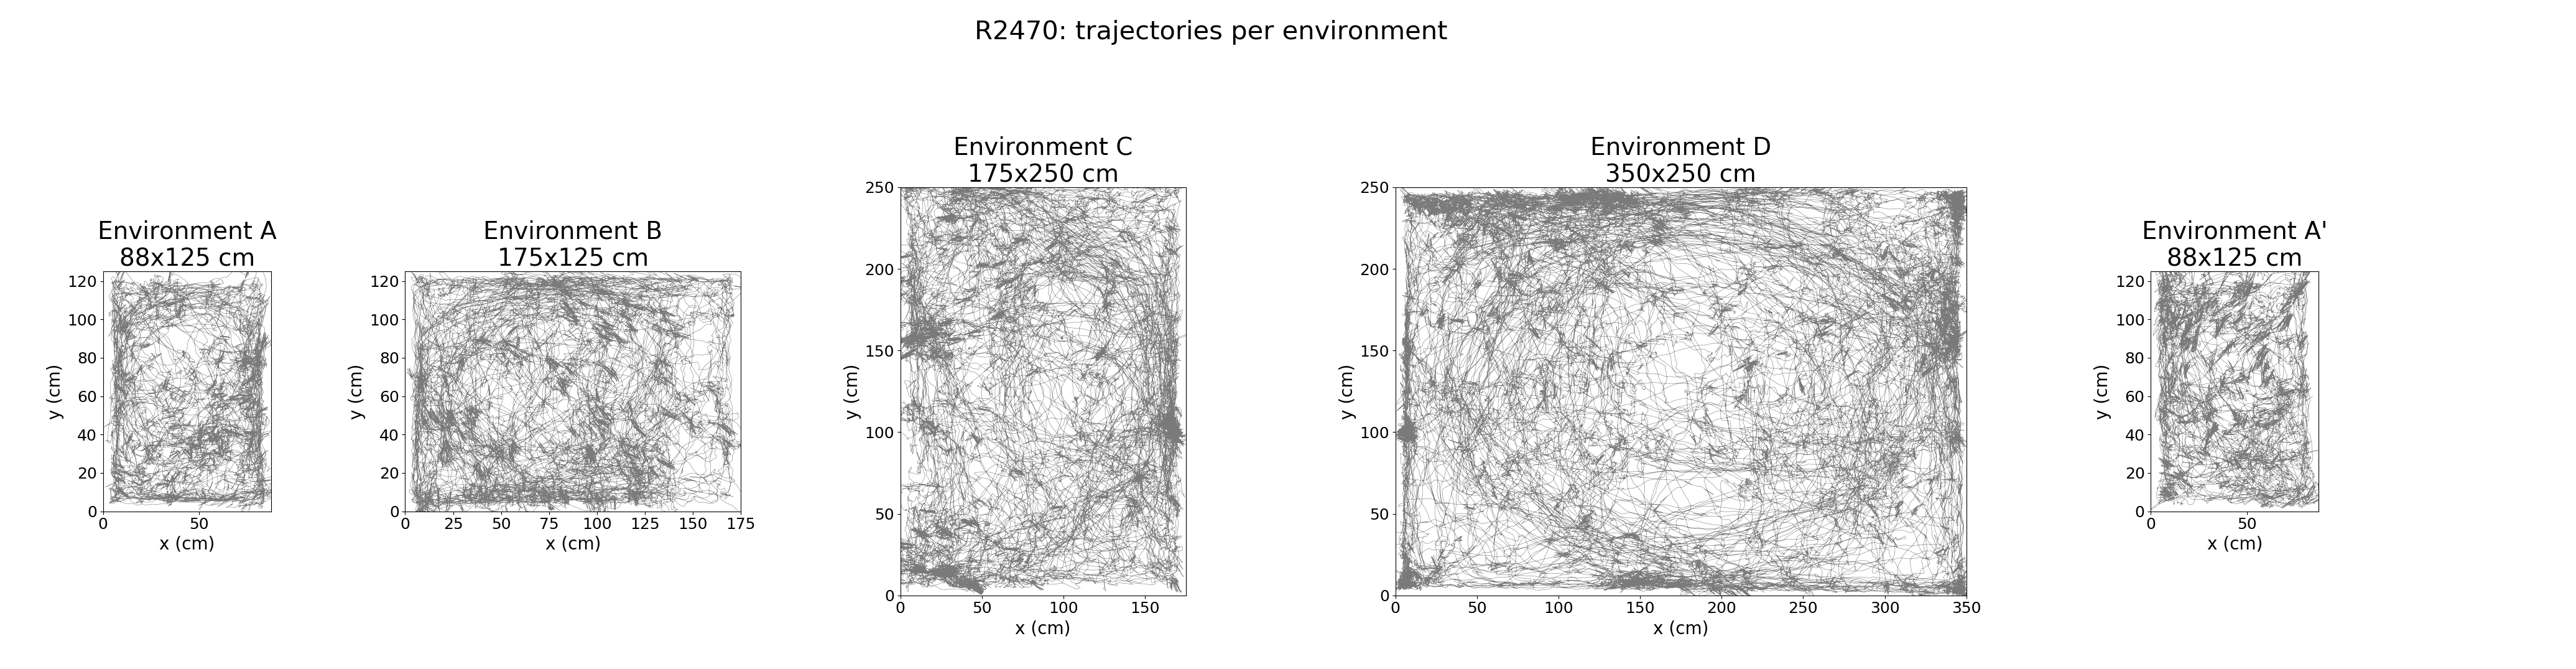

0

In [8]:
import gc
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

EXPERIMENT_LABELS = {
    "exp_scales_a": "A",
    "exp_scales_b": "B",
    "exp_scales_c": "C",
    "exp_scales_d": "D",
    "exp_scales_a2": "A'",
}


def plot_rat_trajectories(experiments, rat_id, stride=1, linewidth=0.4, color="0.35"):
    labels = []
    trajectories = []
    windows = []

    for experiment in experiments:
        if experiment.position is None:
            continue

        xy = np.asarray(experiment.position.xy, dtype=float)
        xy = xy[np.all(np.isfinite(xy), axis=1)]
        if len(xy) == 0:
            continue

        window = None
        for unit in experiment.units:
            spatial = unit.analysis.get("spatial_ratemaps")
            if spatial and "spatial_window" in spatial:
                window = np.asarray(spatial["spatial_window"], dtype=float)
                break
        if window is None:
            window = np.array([xy[:, 0].min(), xy[:, 0].max(), xy[:, 1].min(), xy[:, 1].max()])

        experiment_id = experiment.info.get("experiment_id", "unknown")
        letter = EXPERIMENT_LABELS.get(experiment_id, experiment_id)
        arena_size = np.asarray(experiment.info.get("arena_size", [np.nan, np.nan]), dtype=float)
        label = f"Environment {letter}\n{arena_size[0]:.0f}x{arena_size[1]:.0f} cm"

        labels.append(label)
        trajectories.append(xy)
        windows.append(window)

    if not trajectories:
        print(f"{rat_id}: no environments with usable position data")
        return

    widths = [w[1] - w[0] for w in windows]
    heights = [w[3] - w[2] for w in windows]

    n_environments = len(trajectories)
    fig_width = (sum(widths) * 0.035 + n_environments) / 0.86
    fig_height = max(heights) * 0.035 + 2.0

    fig, axes = plt.subplots(
        1, n_environments,
        figsize=(fig_width, fig_height),
        gridspec_kw={"width_ratios": widths},
    )
    if n_environments == 1:
        axes = [axes]

    for axis, xy, label, window in zip(axes, trajectories, labels, windows):
        axis.plot(xy[::stride, 0], xy[::stride, 1], color=color, linewidth=linewidth, alpha=0.8)
        x_min, x_max, y_min, y_max = window
        axis.set_xlim(x_min, x_max)
        axis.set_ylim(y_min, y_max)
        axis.set_aspect("equal")
        axis.set_title(label, fontsize=28)
        axis.set_xlabel("x (cm)", fontsize=20)
        axis.set_ylabel("y (cm)", fontsize=20)
        axis.tick_params(axis="both", labelsize=18)

    fig.subplots_adjust(top=0.72, left=0.04, right=0.90, wspace=0.4)
    fig.suptitle(f"{rat_id}: trajectories per environment", fontsize=30, x=0.47, y=0.97)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=fig.dpi)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


plot_rat_trajectories(experiments, RAT_ID)
plt.close("all")
gc.collect()

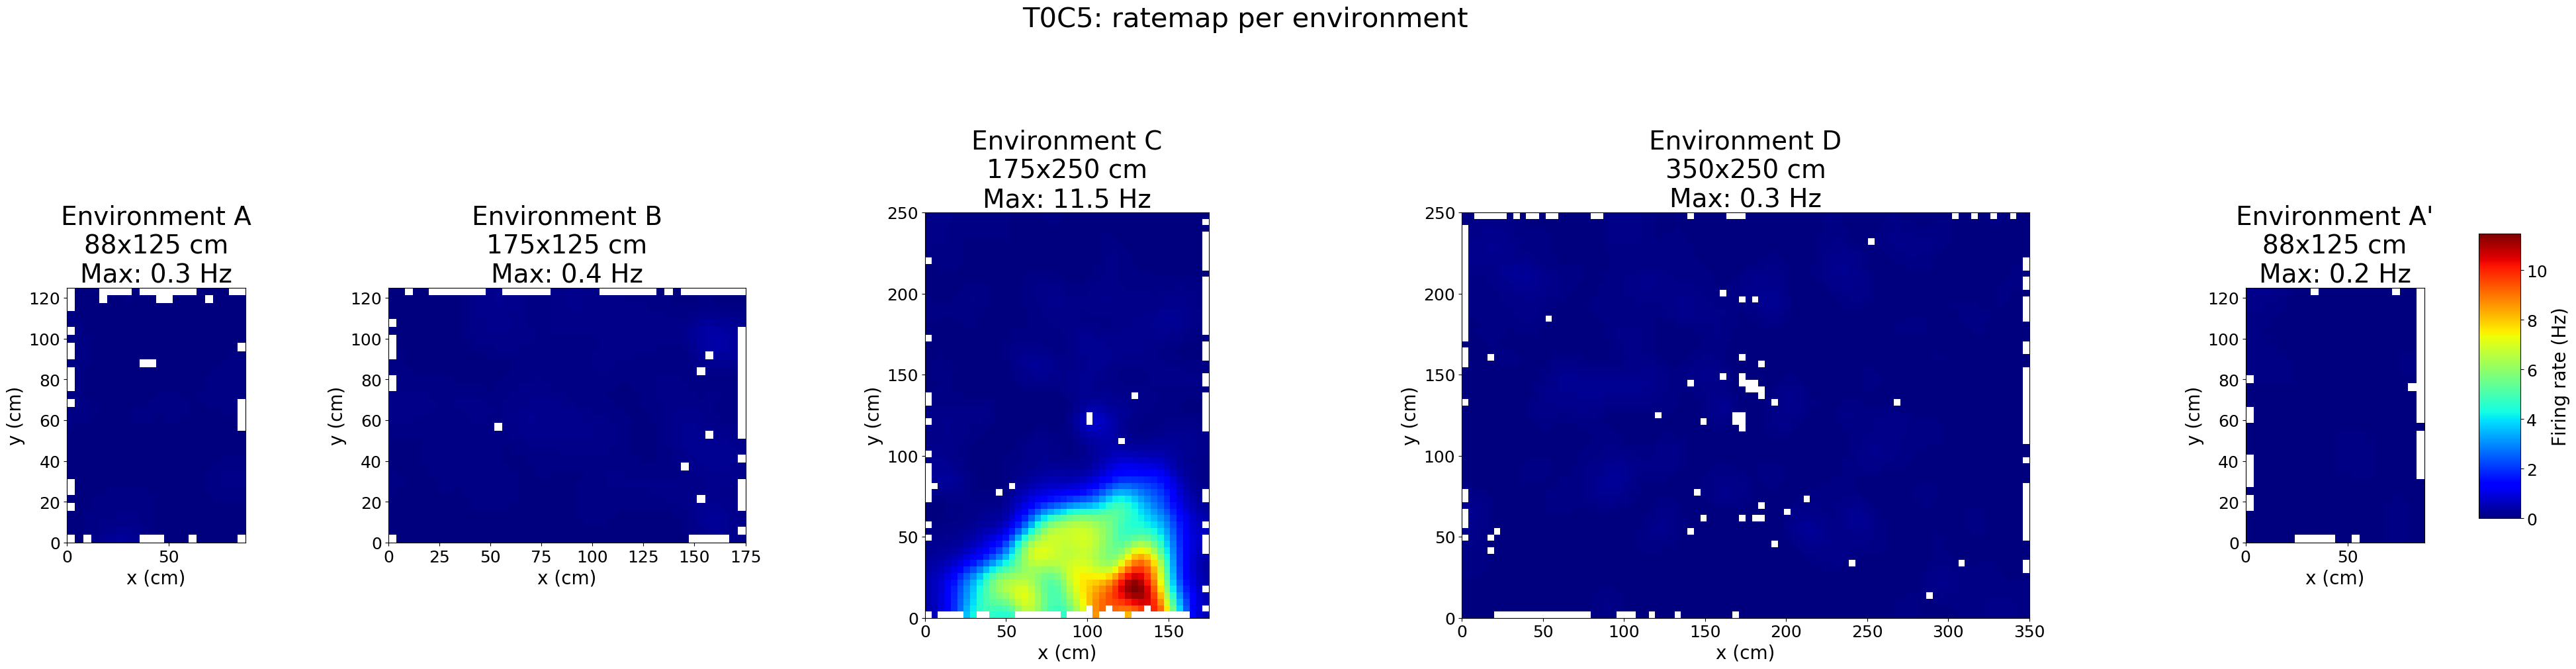

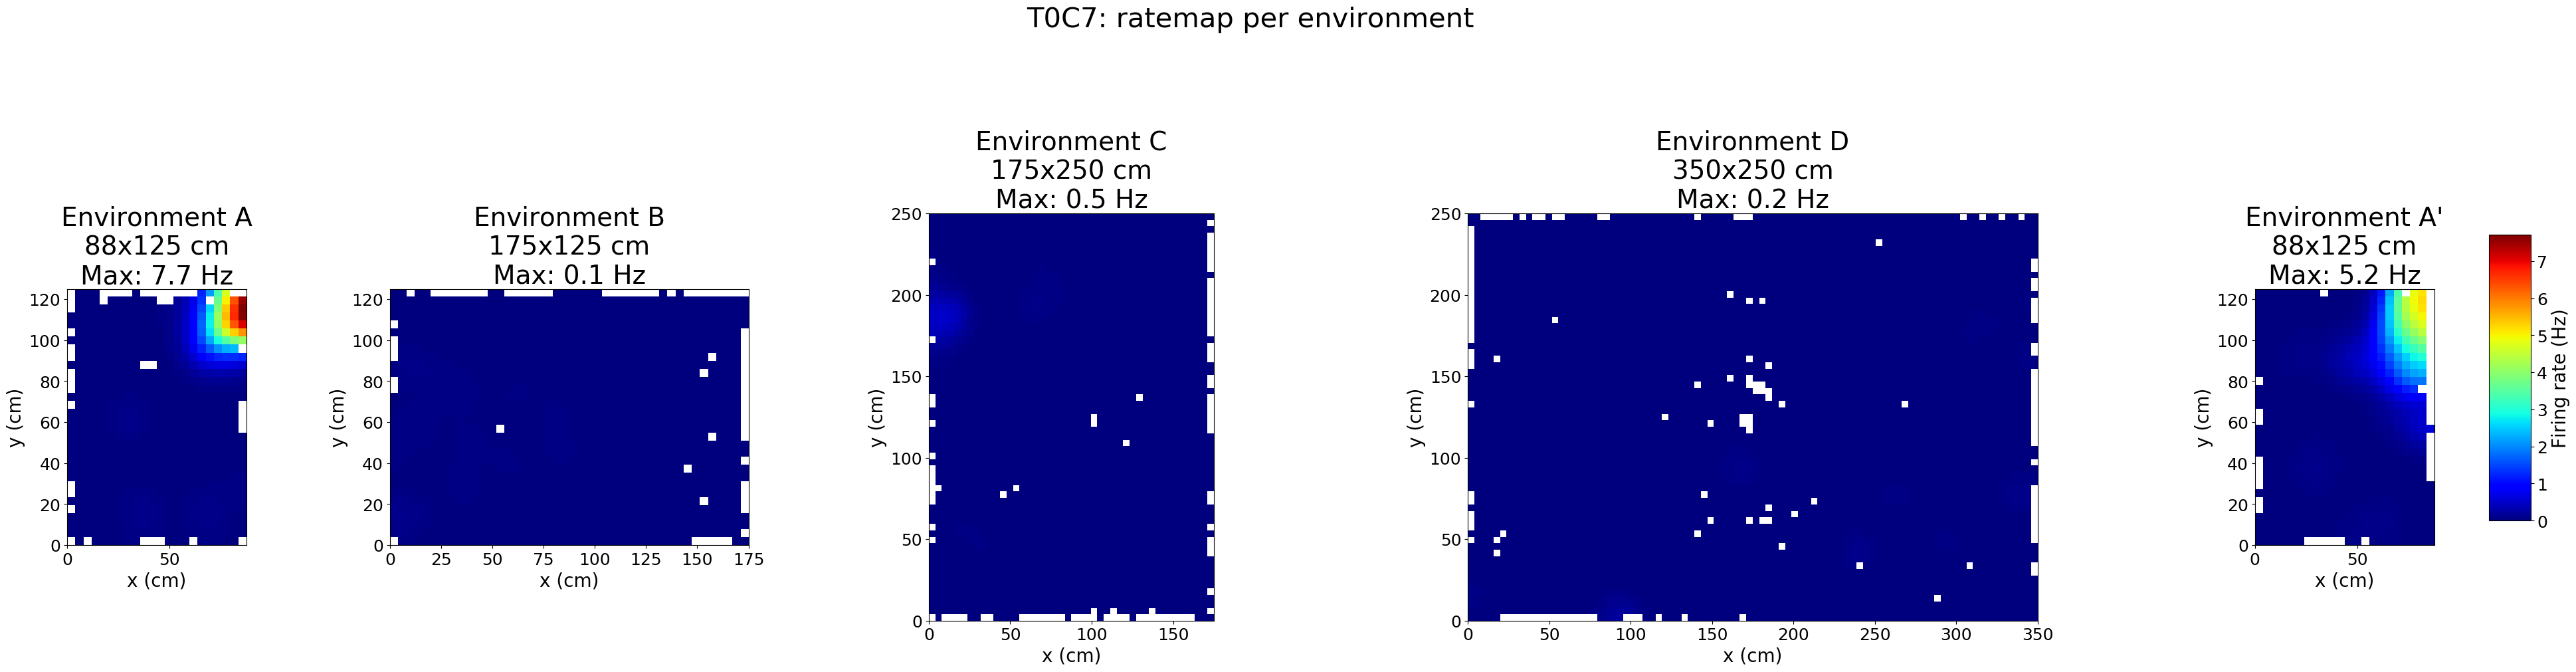

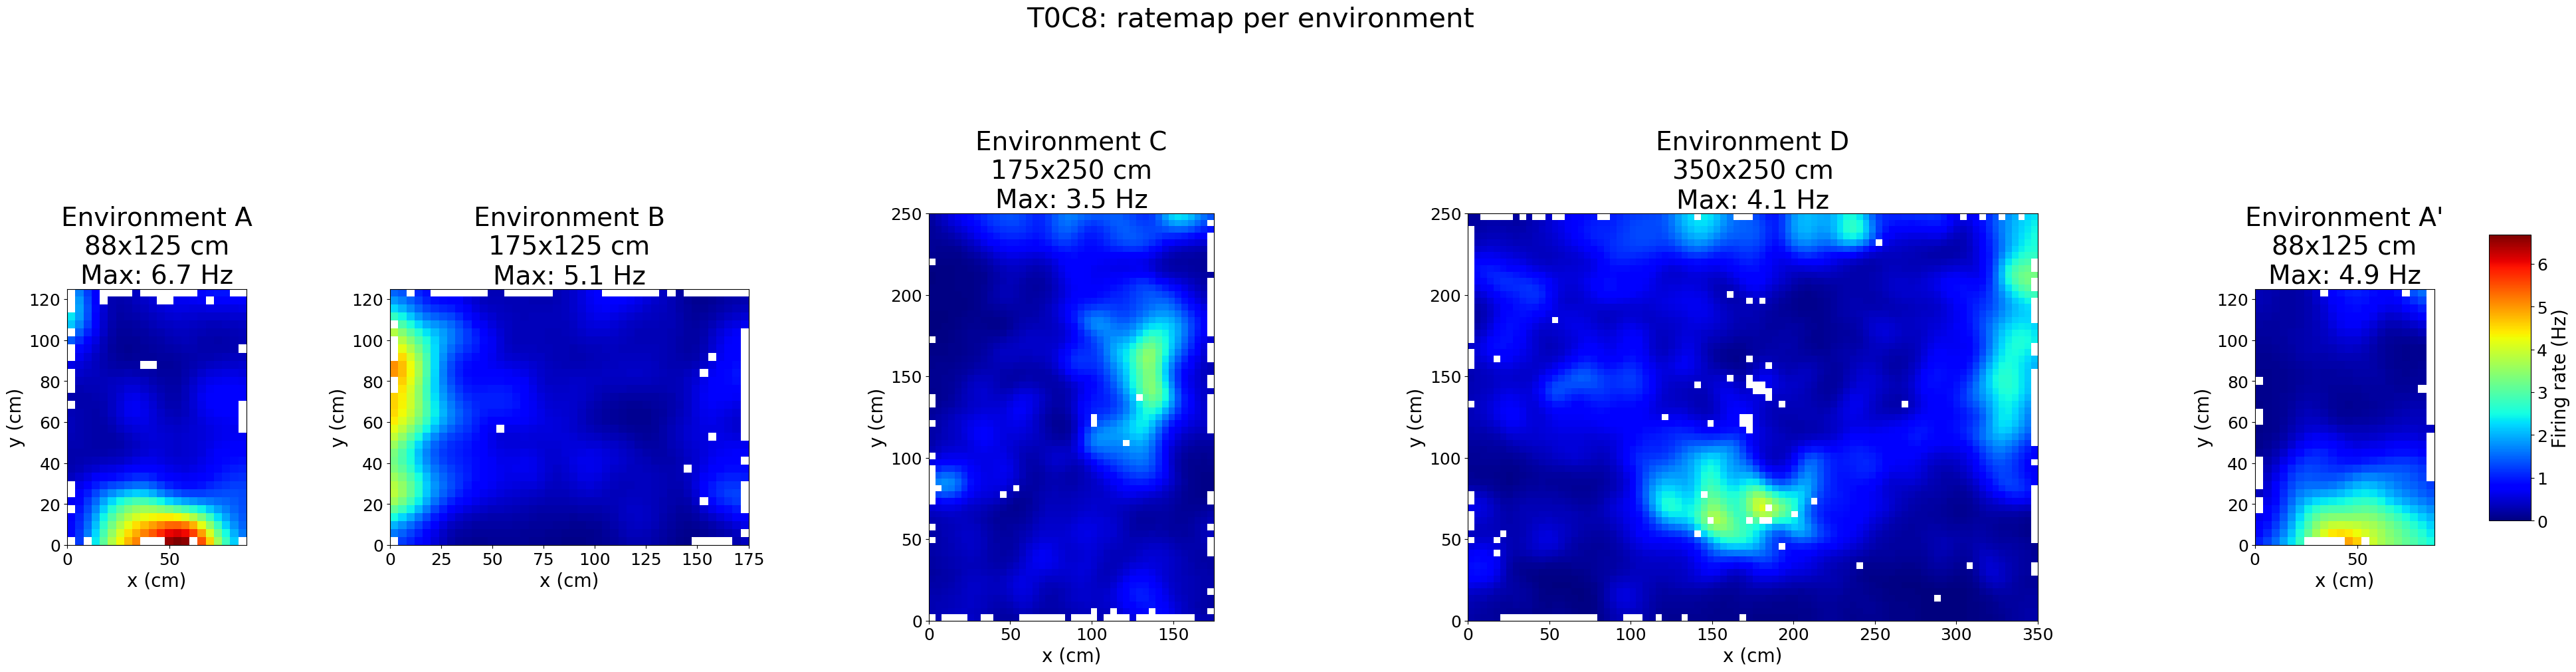

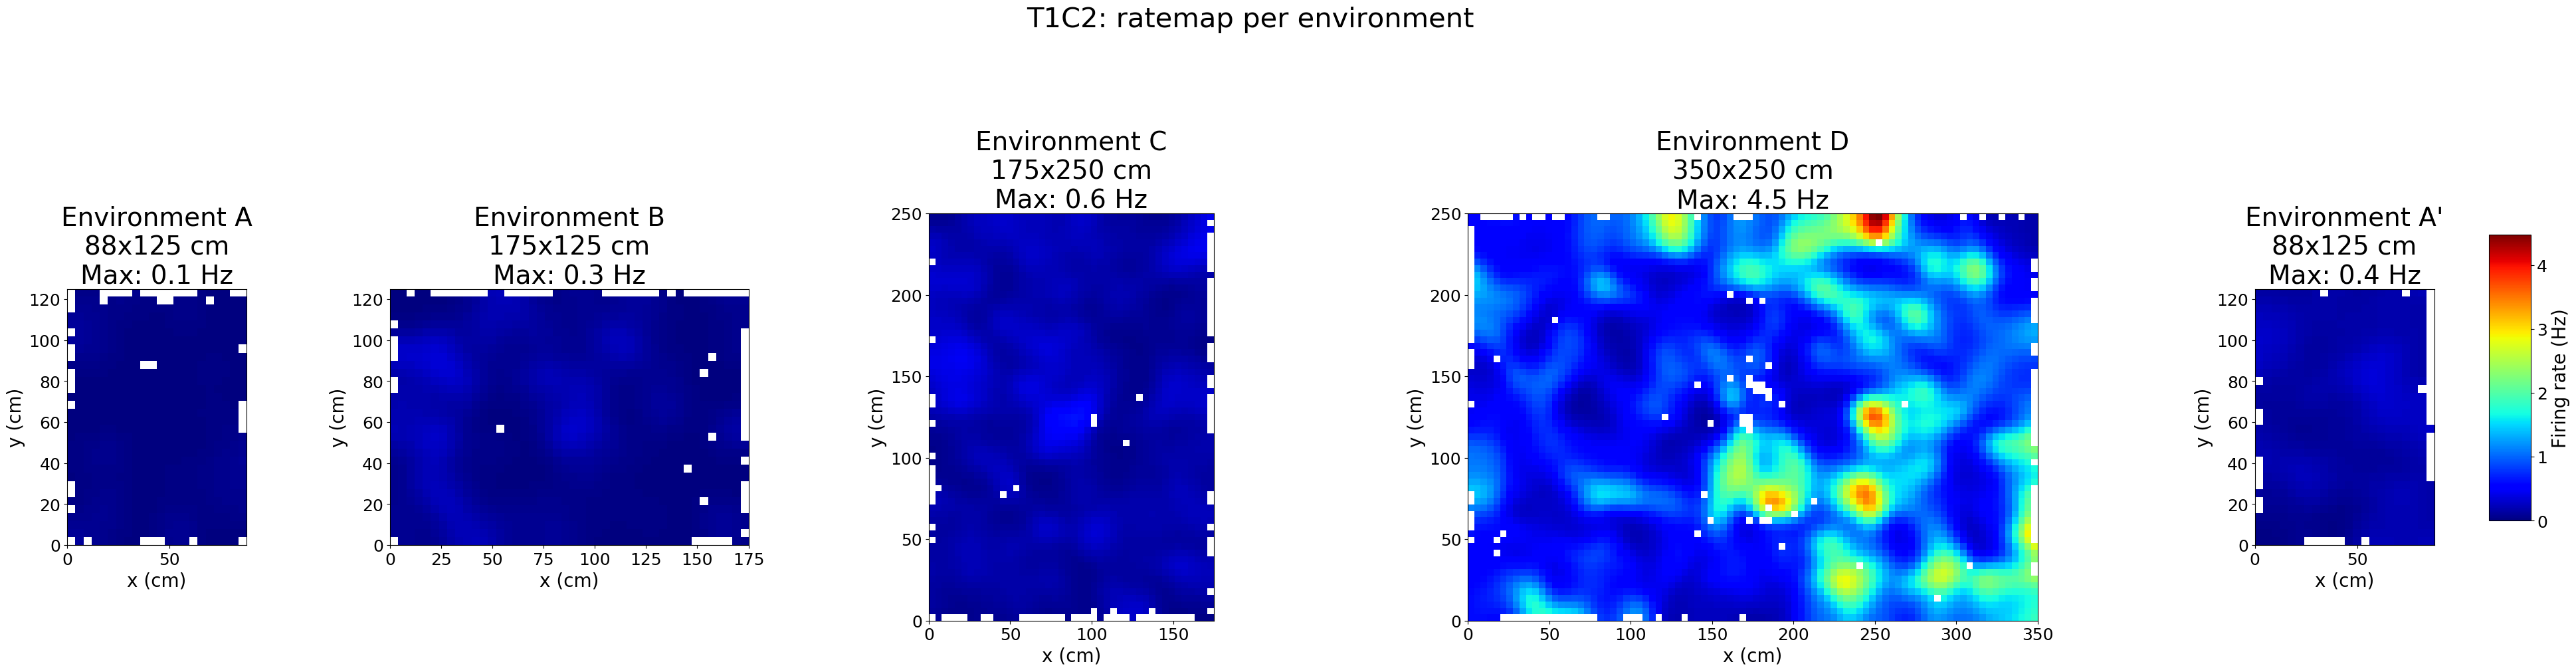

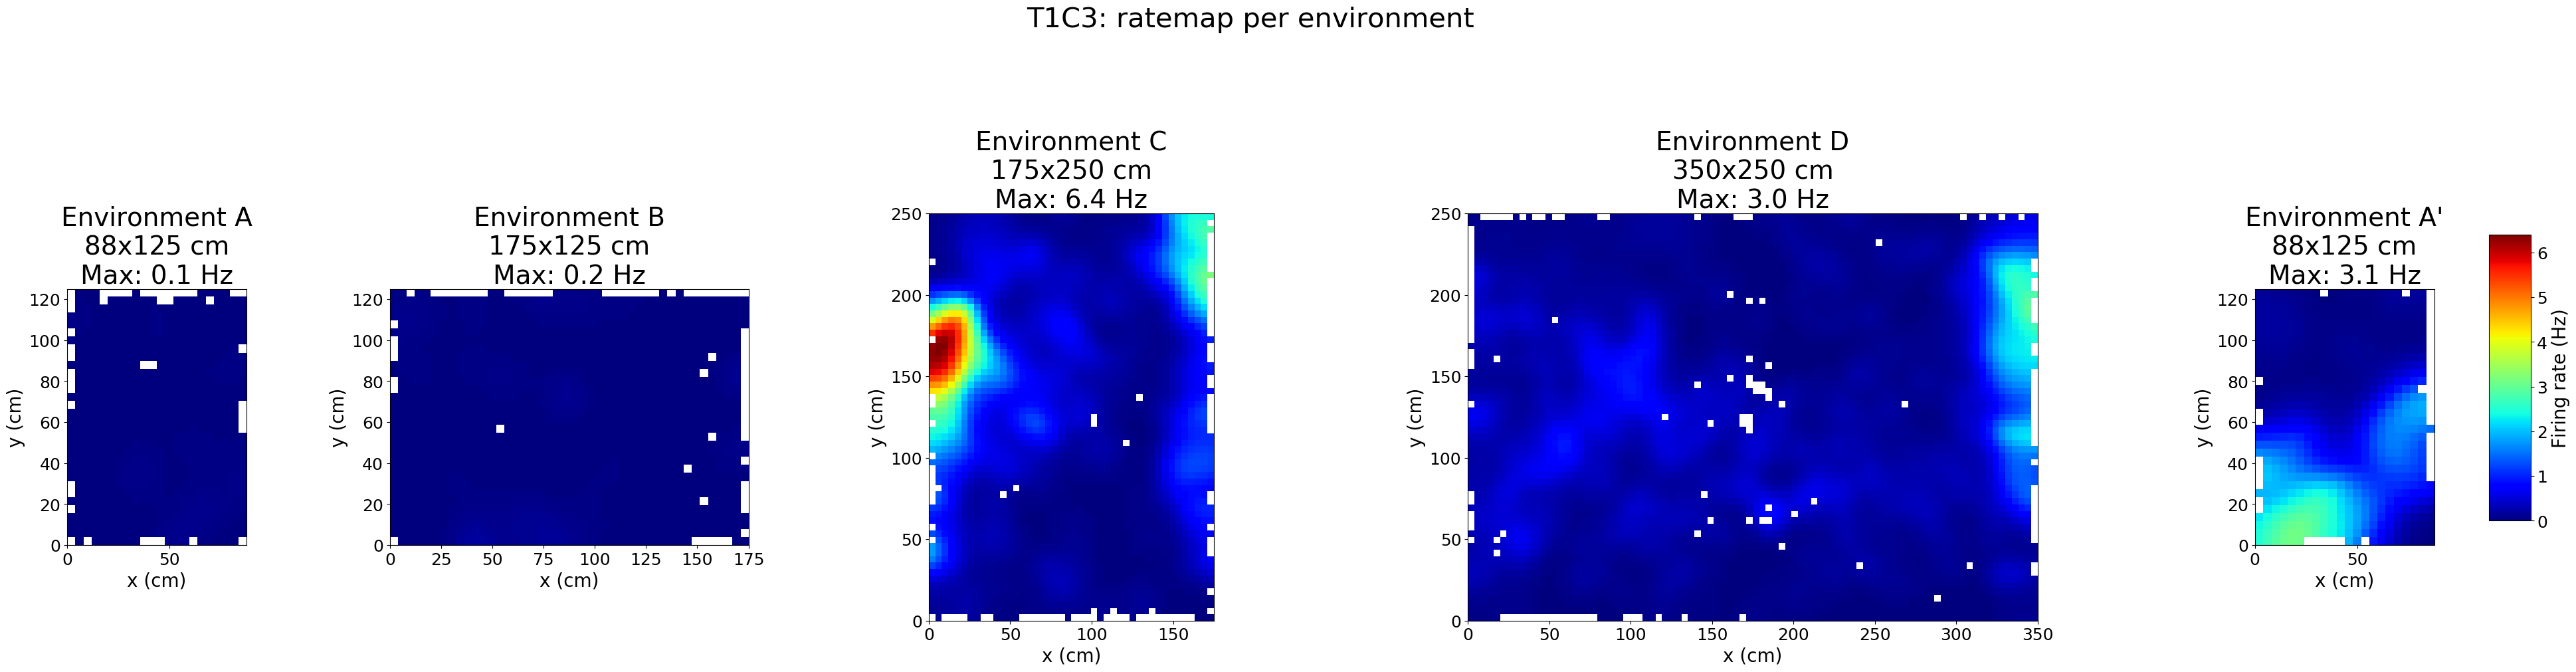

In [ ]:
from collections import defaultdict


def plot_all_cell_ratemaps(experiments, rat_id):
    ratemaps_by_cell = defaultdict(list)

    for experiment in experiments:
        window = None
        for unit in experiment.units:
            spatial = unit.analysis.get("spatial_ratemaps")
            if spatial and "spatial_window" in spatial:
                window = np.asarray(spatial["spatial_window"], dtype=float)
                break

        experiment_id = experiment.info.get("experiment_id", "unknown")
        letter = EXPERIMENT_LABELS.get(experiment_id, experiment_id)
        arena_size = np.asarray(experiment.info.get("arena_size", [np.nan, np.nan]), dtype=float)
        label = f"Environment {letter}\n{arena_size[0]:.0f}x{arena_size[1]:.0f} cm"

        for unit in experiment.units:
            if unit.analysis.get("category") != "place_cell":
                continue
            spatial = unit.analysis["spatial_ratemaps"]
            ratemap = np.asarray(spatial["spike_rates_smoothed"], dtype=float)
            cell_key = (unit.tetrode_nr, unit.cluster_id)
            ratemaps_by_cell[cell_key].append((label, ratemap, window))

    for (tetrode_nr, cluster_id), entries in ratemaps_by_cell.items():
        labels = []
        ratemaps = []
        windows = []

        for label, ratemap, window in entries:
            if window is None:
                n_y, n_x = ratemap.shape
                window = np.array([0, n_x, 0, n_y])
            labels.append(label)
            ratemaps.append(ratemap)
            windows.append(window)

        widths = [w[1] - w[0] for w in windows]
        heights = [w[3] - w[2] for w in windows]

        n_environments = len(ratemaps)
        fig_width = (sum(widths) * 0.035 + n_environments) / 0.86
        fig_height = max(heights) * 0.035 + 2.0

        fig, axes = plt.subplots(
            1, n_environments,
            figsize=(fig_width, fig_height),
            gridspec_kw={"width_ratios": widths},
        )
        if n_environments == 1:
            axes = [axes]

        vmax = max(np.nanmax(ratemap) for ratemap in ratemaps)

        image = None
        for axis, ratemap, label, window in zip(axes, ratemaps, labels, windows):
            ratemap_max = float(np.nanmax(ratemap))
            image = axis.imshow(
                ratemap,
                origin="lower",
                cmap="jet",
                vmin=0,
                vmax=vmax,
                extent=window,
                aspect="equal",
            )
            axis.set_title(f"{label}\nMax: {ratemap_max:.1f} Hz", fontsize=28)
            axis.set_xlabel("x (cm)", fontsize=20)
            axis.set_ylabel("y (cm)", fontsize=20)
            axis.tick_params(axis="both", labelsize=18)

        fig.subplots_adjust(top=0.68, left=0.04, right=0.90, wspace=0.4)

        cax = fig.add_axes([0.92, 0.25, 0.015, 0.4])
        cbar = fig.colorbar(image, cax=cax)
        cbar.ax.tick_params(labelsize=18)
        cbar.set_label("Firing rate (Hz)", fontsize=20)

        fig.suptitle(f"T{tetrode_nr}C{cluster_id}: ratemap per environment", fontsize=30, x=0.47, y=0.97)

        plt.show()
        plt.close(fig)


plot_all_cell_ratemaps(experiments, RAT_ID)

**Building Stacks**

Visualization cells per stack

Overview Plots for all environments 

In [1]:
all_results = {}
for experiment in experiments:
    place_cells = []
    for unit_index, unit in enumerate(experiment.units):
        if unit.analysis.get("category") == "place_cell":
            place_cells.append({
                "experiment": experiment,
                "unit_index": unit_index,
                "unit": unit,
            })

    exp_id = experiment.info.get("experiment_id", id(experiment))
    bin_means, grand_mean = mean_activity_rate_maps(place_cells)
    sw = np.asarray(experiment.units[0].analysis["spatial_ratemaps"]["spatial_window"], dtype=float)
    result = build_active_cell_stacks(
        place_cells=place_cells,
        population_mean_hz=grand_mean,
        arena_spatial_window=sw,
        stack_size_cm=10.0,
        threshold=2.0,
    )
    all_results[exp_id] = result
    plot_active_cell_counts_heatmap(result, title=f"Active cells per bin — {exp_id}")
    plot_active_cells_per_position(result, title=f"Active cells per bin — {exp_id}")
    plot_active_cells_fraction_per_position(result, title=f"Fraction of active cells per bin — {exp_id}")

iy, ix = 1, 1
for cell_info in result["active_cells_per_stack"][iy][ix]:
    print(f"T{cell_info['tetrode']}C{cell_info['cluster']}: {cell_info['rate']:.2f} Hz")

NameError: name 'experiments' is not defined